# E-Commerce Customer Analytics

## Predictive Modeling

This notebook evaluates supervised learning models across four e-commerce datasets to determine where useful predictive signal exists and where it does not.

The modeling workflow follows a consistent structure: define the target, select leakage-aware features, create a train/test split, establish a Random Forest baseline, evaluate cross-validation performance, tune hyperparameters, and review final holdout results.

The four modeling tasks are:

1. **User Behavior & Engagement:** predict `Add to Cart`.
2. **Sales & Customer Insights:** predict continuous `Churn_Probability`.
3. **Customer Churn:** predict binary `Churn`.
4. **Purchase Experience:** identify `High_Value_Order` without using direct transaction-value components.

Model performance is interpreted alongside the earlier exploratory analyses. Feature importance is used for model interpretation, not as evidence of causation.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    r2_score,
    mean_squared_error,
    mean_absolute_error,
)
from sklearn.model_selection import (
    GridSearchCV,
    train_test_split,
    StratifiedKFold,
    KFold,
    cross_val_score,
    cross_validate,
)

DATA_DIR = Path("../data")


## 1. User Behavior & Engagement — Add-to-Cart Classification

The first modeling task predicts `Add to Cart` at the interaction level. The feature set focuses on customer profile, product context, time context, and engagement behavior while excluding identifiers, high-cardinality location fields, and order-stage variables that could introduce leakage.

### 1.1 Load Prepared Data

The cleaned EDA dataset from the data-preparation notebook is used as the modeling starting point.

In [2]:
# Load the cleaned EDA version
df_behavior = pd.read_pickle(DATA_DIR / "df_behavior_eda.pkl")

df_behavior.shape

(51207, 27)

### 1.2 Target Definition and Class Balance

`Add to Cart` is a binary target representing purchase intent. The positive class accounts for about two-thirds of the observations, so stratification and class-sensitive metrics are used during evaluation.

In [3]:
# Check class balance for the target variable

target_behavior = "Add to Cart"
df_behavior[target_behavior].value_counts(normalize=True).round(3)

Add to Cart
1    0.667
0    0.333
Name: proportion, dtype: float64

The target is moderately imbalanced: approximately 66.7% of interactions have `Add to Cart = 1` and 33.3% have `Add to Cart = 0`.

Because the imbalance is not extreme, no resampling is applied. Accuracy is reported alongside precision, recall, F1-score, and the confusion matrix.

### 1.3 Feature Selection and Train/Test Split

Identifier fields are excluded to avoid memorization. `Order Date` is removed while the simpler `Months` feature is retained. High-cardinality location fields (`City`, `State`, and `Country`) are excluded to keep the initial model compact.

Order-stage variables such as `Sales`, `Quantity`, `Discount`, `Profit`, `Shipping Cost`, `Ship Mode`, and `Order Priority` are also excluded because they may contain information that occurs at or after the purchasing stage.

In [4]:
# Review cardinality before feature selection
object_cols_behavior = df_behavior.select_dtypes(include="object").columns

unique_counts_behavior = pd.DataFrame({
    "Column": object_cols_behavior,
    "Unique Values": [df_behavior[col].nunique() for col in object_cols_behavior]}).sort_values("Unique Values", ascending=False)

unique_counts_behavior

,Column,Unique Values
10,Order ID,51191
0,Customer ID,794
1,Customer Name,794
3,City,547
4,State,319
5,Country,84
14,Product,42
6,Region,13
11,Months,12
8,Education,5


In [5]:
target_behavior = "Add to Cart"
y_behavior = df_behavior[target_behavior].copy()

removed_cols_behavior = ["Add to Cart","Customer ID","Customer Name","Order ID","Order Date","City","State", "Country","Sales","Quantity","Discount","Profit","Shipping Cost","Ship Mode","Order Priority",]

X_behavior = df_behavior.drop(columns=removed_cols_behavior).copy()
X_behavior.columns

Index(['Segment', 'Region', 'Gender', 'Age', 'Education', 'Marital Status',
       'Months', 'Product Category', 'Product', 'Browsing Time (min)', 'Like',
       'Share'],
      dtype='object')

In [6]:
# One-hot encode categorical variables
X_behavior_encoded = pd.get_dummies( X_behavior,drop_first=True,dtype=int)

X_train_behavior, X_test_behavior, y_train_behavior, y_test_behavior = train_test_split(X_behavior_encoded,y_behavior,test_size=0.2,random_state=42,stratify=y_behavior)

print("Training shape:", X_train_behavior.shape)
print("Test shape:", X_test_behavior.shape)

print("\nTraining target balance:")
print(y_train_behavior.value_counts(normalize=True).round(3))

print("\nTest target balance:")
print(y_test_behavior.value_counts(normalize=True).round(3))

Training shape: (40965, 79)
Test shape: (10242, 79)

Training target balance:
Add to Cart
1    0.667
0    0.333
Name: proportion, dtype: float64

Test target balance:
Add to Cart
1    0.667
0    0.333
Name: proportion, dtype: float64


### 1.4 Baseline Random Forest

In [7]:
# Build and train the baseline Random Forest model
rf_baseline_behavior = RandomForestClassifier(random_state=42)
rf_baseline_behavior.fit(X_train_behavior, y_train_behavior)

# Make predictions on the test set
y_pred_baseline_behavior = rf_baseline_behavior.predict(X_test_behavior)

# Evaluate the baseline model
baseline_accuracy_behavior = accuracy_score(y_test_behavior,y_pred_baseline_behavior)

print("Baseline Random Forest Accuracy:", round(baseline_accuracy_behavior, 3))
print("\nClassification Report:")
print(classification_report(y_test_behavior, y_pred_baseline_behavior))

Baseline Random Forest Accuracy: 0.69

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.52      0.53      3411
           1       0.76      0.78      0.77      6831

    accuracy                           0.69     10242
   macro avg       0.65      0.65      0.65     10242
weighted avg       0.69      0.69      0.69     10242



Baseline Confusion Matrix:
[[1771 1640]
 [1536 5295]]


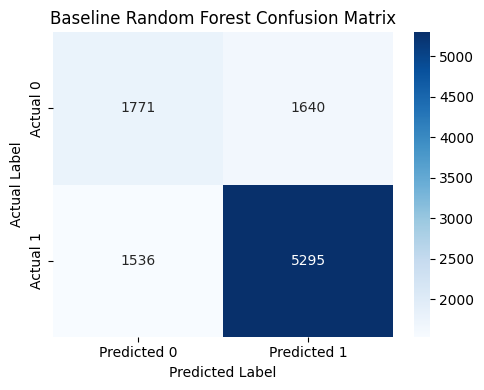

In [8]:
# Confusion matrix for the baseline model
baseline_cm_behavior = confusion_matrix(y_test_behavior,y_pred_baseline_behavior)
print(f"Baseline Confusion Matrix:\n{baseline_cm_behavior}")

# Plot confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(baseline_cm_behavior,annot=True,fmt="d",cmap="Blues", xticklabels=["Predicted 0", "Predicted 1"],yticklabels=["Actual 0", "Actual 1"])

plt.title("Baseline Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

The baseline Random Forest achieves about **0.690 accuracy** and **0.648 macro F1** on the holdout set. Performance is stronger for the majority `Add to Cart = 1` class, so accuracy alone would overstate how evenly the model performs across both classes.

### 1.5 Cross-Validation

Five-fold stratified cross-validation is used on the training data to evaluate whether baseline performance is stable across different folds.

In [9]:
cv_behavior = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

cv_accuracy_scores_behavior = cross_val_score(rf_baseline_behavior,X_train_behavior,y_train_behavior,cv=cv_behavior,scoring="accuracy")

print("CV Accuracy Scores:", cv_accuracy_scores_behavior.round(3))
print("Mean CV Accuracy:", round(cv_accuracy_scores_behavior.mean(), 3))
print("CV Accuracy Std:", round(cv_accuracy_scores_behavior.std(), 3))

CV Accuracy Scores: [0.689 0.69  0.689 0.685 0.695]
Mean CV Accuracy: 0.689
CV Accuracy Std: 0.003


In [10]:
cv_f1_scores_behavior = cross_val_score(rf_baseline_behavior,X_train_behavior,y_train_behavior,cv=cv_behavior,scoring="f1_macro")

print("CV Macro F1 Scores:", cv_f1_scores_behavior.round(3))
print("Mean CV Macro F1:", round(cv_f1_scores_behavior.mean(), 3))
print("CV Macro F1 Std:", round(cv_f1_scores_behavior.std(), 3))

CV Macro F1 Scores: [0.644 0.648 0.647 0.646 0.654]
Mean CV Macro F1: 0.648
CV Macro F1 Std: 0.003


Cross-validation closely matches the holdout result, with mean accuracy of about **0.689** and mean macro F1 of about **0.648**. The small fold-to-fold variation suggests stable but moderate predictive performance.

### 1.6 Hyperparameter Tuning

Grid search optimizes macro F1 so that both classes contribute equally to model selection.

In [11]:
# Define a small hyperparameter grid
param_grid_behavior = {
    "n_estimators": [200, 300, 400],
    "max_depth": [None, 10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "class_weight": [None, "balanced"]
}

# Set up GridSearchCV
grid_search_behavior = GridSearchCV(estimator=RandomForestClassifier(random_state=42),param_grid=param_grid_behavior,cv=cv_behavior,scoring="f1_macro",n_jobs=-1)

# Run hyperparameter tuning
grid_search_behavior.fit(X_train_behavior, y_train_behavior)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'class_weight': [None, 'balanced'], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [12]:
# Show best parameters and best cross-validation score
print("Best Parameters:")
print(grid_search_behavior.best_params_)

print("\nBest CV Macro F1:")
print(round(grid_search_behavior.best_score_, 3))

Best Parameters:
{'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}

Best CV Macro F1:
0.69


### 1.7 Final Tuned Model Evaluation

The best cross-validated Random Forest is evaluated once on the holdout test set.

In [13]:
best_rf_behavior = grid_search_behavior.best_estimator_

y_pred_best_behavior = best_rf_behavior.predict(X_test_behavior)

best_accuracy_behavior = accuracy_score(y_test_behavior,y_pred_best_behavior)

best_macro_f1_behavior = f1_score(y_test_behavior,y_pred_best_behavior,average="macro")

print("Tuned Random Forest Accuracy:", round(best_accuracy_behavior, 3))
print("Tuned Random Forest Macro F1:", round(best_macro_f1_behavior, 3))

print("\nClassification Report:")
print(classification_report(y_test_behavior, y_pred_best_behavior))

Tuned Random Forest Accuracy: 0.698
Tuned Random Forest Macro F1: 0.691

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.81      0.64      3411
           1       0.87      0.64      0.74      6831

    accuracy                           0.70     10242
   macro avg       0.70      0.73      0.69     10242
weighted avg       0.76      0.70      0.71     10242



tuned model confusion matrix:
[[2769  642]
 [2447 4384]]


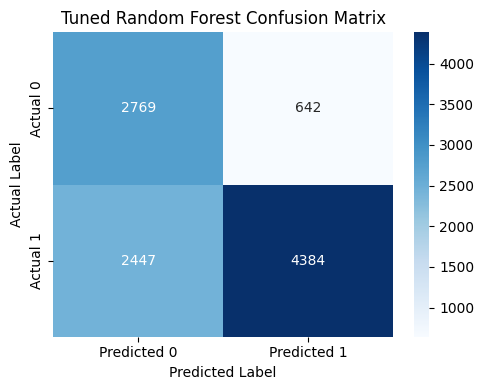

In [14]:
# Confusion matrix for the tuned model
best_cm_behavior = confusion_matrix( y_test_behavior,y_pred_best_behavior)
print(f"tuned model confusion matrix:\n{best_cm_behavior}")

# Plot confusion matrix for the tuned model
plt.figure(figsize=(5, 4))
sns.heatmap(best_cm_behavior,annot=True,fmt="d",cmap="Blues",xticklabels=["Predicted 0", "Predicted 1"],yticklabels=["Actual 0", "Actual 1"])

plt.title("Tuned Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [15]:
baseline_macro_f1_behavior = f1_score(y_test_behavior,y_pred_baseline_behavior,average="macro")

model_comparison_behavior = pd.DataFrame({
    "Model": ["Baseline Random Forest", "Tuned Random Forest"],
    "Test Accuracy": [baseline_accuracy_behavior, best_accuracy_behavior],
    "Test Macro F1": [baseline_macro_f1_behavior, best_macro_f1_behavior],
})

model_comparison_behavior

,Model,Test Accuracy,Test Macro F1
0,Baseline Random Forest,0.689904,0.648263
1,Tuned Random Forest,0.698399,0.690708


The tuned model improves the balance between classes. Test accuracy increases slightly from about **0.690 to 0.698**, while macro F1 improves from about **0.648 to 0.691**.

Balanced class weights substantially increase recall for `Add to Cart = 0` (to about 0.81), but recall for `Add to Cart = 1` falls to about 0.64. The result is therefore a clearer class-performance trade-off rather than a large gain in overall accuracy.

### 1.8 Feature Importance

Feature importance is reviewed from the tuned Random Forest to identify which variables contributed most to prediction. These values describe model usage, not causal effects.

In [16]:
feature_importance_behavior = pd.DataFrame({
    "Feature": X_train_behavior.columns,
    "Importance": best_rf_behavior.feature_importances_}).sort_values("Importance",ascending=False).reset_index(drop=True)

feature_importance_behavior.head(15)

,Feature,Importance
0,Share,0.193871
1,Like,0.140103
2,Browsing Time (min),0.109814
3,Gender_Male,0.081677
4,Age,0.068028
5,Product Category_Fashion,0.029857
6,Product Category_Home & Furniture,0.018159
7,Marital Status_Single,0.014801
8,Segment_Corporate,0.013717
9,Segment_Home Office,0.011227


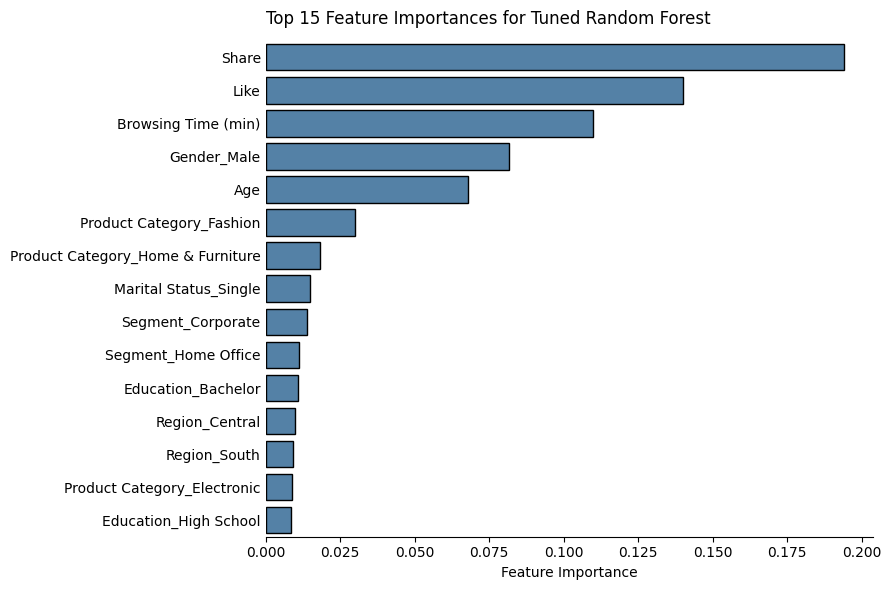

In [17]:
top_features_behavior = feature_importance_behavior.head(15)

plt.figure(figsize=(9, 6))
ax = sns.barplot(data=top_features_behavior,x="Importance",y="Feature",color="steelblue",edgecolor="black")

plt.title("Top 15 Feature Importances for Tuned Random Forest",fontsize=12,loc="left",pad=12)
plt.xlabel("Feature Importance")
plt.ylabel(None)
plt.tick_params(axis="y", length=0, labelsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

`Share`, `Like`, and `Browsing Time (min)` are the strongest predictors in the tuned model. Engagement variables therefore provide more predictive signal for add-to-cart behavior than most profile or contextual variables in this feature set.

`Gender` and `Age` also contribute, while product category, segment, education, and region have smaller individual importance values.

### 1.9 Modeling Summary

Dataset 1 contains a **moderate and stable predictive signal** for add-to-cart behavior. Hyperparameter tuning improves class balance more than overall accuracy, and engagement variables are the most informative features.

The tuned model reaches approximately **0.698 test accuracy** and **0.691 macro F1**, providing a useful baseline for purchase-intent prediction without relying on transaction-stage variables.

## 2. Sales & Customer Insights — Churn Probability Regression

Dataset 2 uses continuous `Churn_Probability` as the regression target. This section intentionally retains the weak modeling result because determining that a dataset has limited predictive value is itself an important analytical outcome.

### 2.1 Load Prepared Data

In [18]:
df_sales = pd.read_pickle(DATA_DIR / "df_sales_eda.pkl")

df_sales.shape

(10000, 15)

### 2.2 Target and Feature Preparation

`Churn_Probability` ranges from 0 to 1 and is modeled as a continuous target. Identifier and date fields are excluded, while the remaining categorical variables are one-hot encoded.

In [19]:
# Target selection
target_sales = "Churn_Probability"
y_sales = df_sales[target_sales]

y_sales.describe()

count    10000.000000
mean         0.501552
std          0.288289
min          0.000000
25%          0.250000
50%          0.500000
75%          0.750000
max          1.000000
Name: Churn_Probability, dtype: float64

In [20]:
target_sales = "Churn_Probability"

drop_cols_sales = ["Churn_Probability","Customer_ID","Product_ID","Transaction_ID","Launch_Date","Peak_Sales_Date",]

X_sales = df_sales.drop(columns=drop_cols_sales)
y_sales = df_sales[target_sales]

categorical_features_sales = ["Most_Frequent_Category","Region","Season","Preferred_Purchase_Times","Retention_Strategy",]

X_sales_encoded = pd.get_dummies(X_sales,columns=categorical_features_sales,drop_first=True,dtype=int)

X_train_sales, X_test_sales, y_train_sales, y_test_sales = train_test_split(X_sales_encoded,y_sales,test_size=0.2,random_state=42)

print("Training shape:", X_train_sales.shape)
print("Test shape:", X_test_sales.shape)

Training shape: (8000, 17)
Test shape: (2000, 17)


### 2.3 Baseline Random Forest

In [21]:
# Create baseline model
rf_sales_baseline = RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)
rf_sales_baseline.fit(X_train_sales, y_train_sales)

# Predict on test set
y_pred_sales_baseline = rf_sales_baseline.predict(X_test_sales)

# Evaluate model
baseline_r2_sales = r2_score(y_test_sales, y_pred_sales_baseline)
baseline_mse_sales = mean_squared_error(y_test_sales, y_pred_sales_baseline)
baseline_rmse_sales = np.sqrt(baseline_mse_sales)
baseline_mae_sales = mean_absolute_error(y_test_sales, y_pred_sales_baseline)

print("Baseline Test R2:", baseline_r2_sales)
print("Baseline Test MSE:", baseline_mse_sales)
print("Baseline Test RMSE:", baseline_rmse_sales)
print("Baseline Test MAE:", baseline_mae_sales)

Baseline Test R2: -0.026237950409428556
Baseline Test MSE: 0.08438793085999999
Baseline Test RMSE: 0.2904960083374641
Baseline Test MAE: 0.24943939999999998


The baseline model has a **negative test R² (-0.026)**, meaning it performs worse than predicting the target mean. RMSE is about **0.290** and MAE about **0.249** on a target bounded between 0 and 1.

This result is consistent with the weak relationships observed during EDA.

### 2.4 Cross-Validation

Five-fold K-fold cross-validation tests whether the weak baseline result persists across different splits.

In [22]:
cv_sales = KFold(n_splits=5,shuffle=True,random_state=42)
scoring_sales = {"r2": "r2","mse": "neg_mean_squared_error","mae": "neg_mean_absolute_error"}
cv_results_sales = cross_validate(rf_sales_baseline, X_sales_encoded, y_sales,cv=cv_sales,scoring=scoring_sales,n_jobs=-1)

cv_r2_scores_sales = cv_results_sales["test_r2"]
cv_mse_scores_sales = -cv_results_sales["test_mse"]
cv_mae_scores_sales = -cv_results_sales["test_mae"]

print("CV R2 scores:", cv_r2_scores_sales)
print("Mean CV R2:", cv_r2_scores_sales.mean())
print("Std CV R2:", cv_r2_scores_sales.std())

print("\nMean CV MSE:", cv_mse_scores_sales.mean())
print("Mean CV RMSE:", np.sqrt(cv_mse_scores_sales.mean()))
print("Mean CV MAE:", cv_mae_scores_sales.mean())

CV R2 scores: [-0.03403852 -0.04354642 -0.06129759 -0.04684637 -0.03763838]
Mean CV R2: -0.044673456514722876
Std CV R2: 0.009433426838178058

Mean CV MSE: 0.086788378128
Mean CV RMSE: 0.2945986729909013
Mean CV MAE: 0.25290042


All five cross-validation R² scores are negative, with a mean of about **-0.045**. Mean CV RMSE is about **0.295** and mean MAE about **0.253**.

The low variation across folds indicates that the weak predictive performance is consistent rather than the result of one unfavorable train/test split.

### 2.5 Hyperparameter Tuning

Grid search tests whether a smaller or more regularized Random Forest can reduce error.

In [23]:
# Hyperparameter tuning for Random Forest Regressor
rf_sales = RandomForestRegressor(random_state=42,n_jobs=-1)

param_grid_sales = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 3],
}

grid_sales = GridSearchCV(estimator=rf_sales,param_grid=param_grid_sales,cv=cv_sales,scoring="neg_mean_squared_error",n_jobs=-1)
grid_sales.fit(X_train_sales, y_train_sales)

print("Best parameters:")
print(grid_sales.best_params_)

print("\nBest CV MSE:")
print(-grid_sales.best_score_)

print("\nBest CV RMSE:")
print(np.sqrt(-grid_sales.best_score_))

Best parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best CV MSE:
0.08363340496929299

Best CV RMSE:
0.2891944068776106


Tuning reduces CV RMSE slightly to about **0.289**, but the improvement is too small to change the overall conclusion.

### 2.6 Final Tuned Model Evaluation

In [24]:
# Final tuned model evaluation

best_rf_sales = grid_sales.best_estimator_

# Predict on the test set
y_pred_sales_tuned = best_rf_sales.predict(X_test_sales)

# Evaluate tuned model
tuned_r2_sales = r2_score(y_test_sales, y_pred_sales_tuned)
tuned_mse_sales = mean_squared_error(y_test_sales, y_pred_sales_tuned)
tuned_rmse_sales = np.sqrt(tuned_mse_sales)
tuned_mae_sales = mean_absolute_error(y_test_sales, y_pred_sales_tuned)

print("Tuned Test R2:", tuned_r2_sales)
print("Tuned Test MSE:", tuned_mse_sales)
print("Tuned Test RMSE:", tuned_rmse_sales)
print("Tuned Test MAE:", tuned_mae_sales)

Tuned Test R2: -0.002908796966028193
Tuned Test MSE: 0.08246956583849736
Tuned Test RMSE: 0.28717514836506547
Tuned Test MAE: 0.24795054750420423


The tuned model still produces a slightly negative test R² (**-0.003**) with RMSE about **0.287** and MAE about **0.248**. Hyperparameter tuning therefore does not uncover a meaningful predictive relationship.

### 2.7 Modeling Summary

Dataset 2 does **not** provide a useful supervised-learning signal for predicting `Churn_Probability`. The baseline and tuned Random Forest models both fail to outperform a simple mean-based prediction in terms of R², and cross-validation confirms that this result is stable.

Together with the earlier exploratory results, the weak signal suggests that this dataset may be highly simplified or synthetic-like, although that cannot be established from model performance alone. Dataset 2 is therefore retained as a documented negative result rather than used as a primary predictive dataset.

## 3. Customer Churn — Churn Classification

Dataset 3 models the binary `Churn` target. Because the positive class represents only about 17% of customers, stratified splitting and macro F1 are used alongside accuracy.

### 3.1 Load Prepared Data

The EDA version is loaded so that the modeling workflow can explicitly handle the seven numerical variables with missing values.

In [25]:
df_churn = pd.read_pickle(DATA_DIR / "df_churn_eda.pkl")

df_churn.shape

(5630, 20)

### 3.2 Target Definition and Class Balance

          Count  Percentage
Churn                      
No Churn   4682   83.161634
Churn       948   16.838366


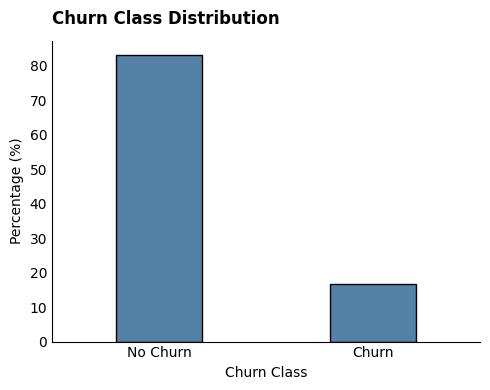

In [26]:
# Target selection and target balance check
target_col_churn = "Churn"

churn_counts = df_churn[target_col_churn].value_counts().sort_index()
churn_percent = df_churn[target_col_churn].value_counts(normalize=True).sort_index() * 100

target_balance_churn = pd.DataFrame({"Count": churn_counts,"Percentage": churn_percent})

target_balance_churn.index = target_balance_churn.index.map({0: "No Churn",1: "Churn"})

print(target_balance_churn)

plt.figure(figsize=(5, 4))

ax = sns.barplot(x=target_balance_churn.index,y=target_balance_churn["Percentage"],color="steelblue",edgecolor="black",width=0.4)

ax.set_title("Churn Class Distribution", loc="left", fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Churn Class")
ax.set_ylabel("Percentage (%)")
ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

The target is imbalanced: approximately **83.2%** of customers did not churn and **16.8%** churned. Precision, recall, macro F1, and the confusion matrix are therefore considered alongside accuracy.

### 3.3 Feature Preparation and Train/Test Split

`CustomerID` is excluded as an identifier. Missing-value indicators are added before median imputation so that potentially informative missingness is retained. Categorical variables are one-hot encoded, and a stratified split preserves the churn rate across training and test sets.

In [27]:
df_churn_model = df_churn.copy()

missing_cols_churn = ["DaySinceLastOrder","OrderAmountHikeFromlastYear","Tenure","OrderCount","CouponUsed","HourSpendOnApp","WarehouseToHome",]

for col in missing_cols_churn:
    df_churn_model[f"{col}_was_missing"] = (df_churn_model[col].isna().astype(int))

for col in missing_cols_churn:
    df_churn_model[col] = df_churn_model[col].fillna(df_churn_model[col].median())

categorical_cols_churn = ["PreferredLoginDevice","PreferredPaymentMode","Gender","PreferedOrderCat","MaritalStatus",]

df_churn_model = pd.get_dummies(df_churn_model,columns=categorical_cols_churn,drop_first=True)

y_churn = df_churn_model["Churn"]
X_churn = df_churn_model.drop(columns=["Churn", "CustomerID"])

X_train_churn, X_test_churn, y_train_churn, y_test_churn = train_test_split( X_churn,y_churn,test_size=0.2, random_state=42, stratify=y_churn)

print("Original EDA version shape:", df_churn.shape)
print("Model-ready version shape:", df_churn_model.shape)
print("\nTraining shape:", X_train_churn.shape)
print("Test shape:", X_test_churn.shape)
print("\nMissing values after modeling preparation:", X_churn.isna().sum().sum())
print("\nTraining target distribution:")
print(y_train_churn.value_counts(normalize=True) * 100)
print("\nTest target distribution:")
print(y_test_churn.value_counts(normalize=True) * 100)

Original EDA version shape: (5630, 20)
Model-ready version shape: (5630, 34)

Training shape: (4504, 32)
Test shape: (1126, 32)

Missing values after modeling preparation: 0

Training target distribution:
Churn
0    83.170515
1    16.829485
Name: proportion, dtype: float64

Test target distribution:
Churn
0    83.12611
1    16.87389
Name: proportion, dtype: float64


### 3.4 Baseline Random Forest

Baseline Test Accuracy: 0.9831261101243339

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.98      1.00      0.99       936
       Churn       0.99      0.91      0.95       190

    accuracy                           0.98      1126
   macro avg       0.99      0.95      0.97      1126
weighted avg       0.98      0.98      0.98      1126



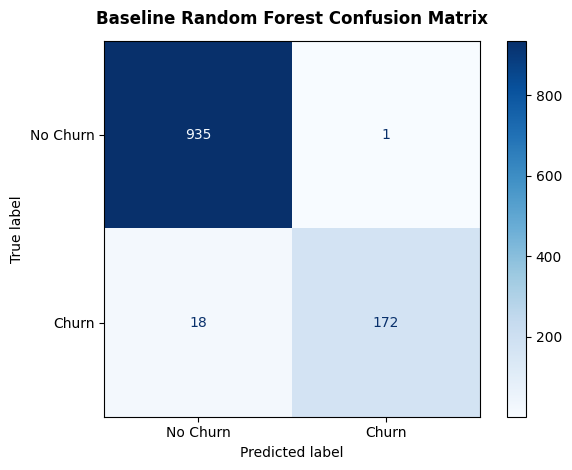

In [28]:
# Baseline Random Forest classifier
rf_baseline_churn = RandomForestClassifier(random_state=42,n_jobs=-1)
rf_baseline_churn.fit(X_train_churn, y_train_churn)

y_pred_baseline_churn = rf_baseline_churn.predict(X_test_churn)
baseline_accuracy_churn = accuracy_score(y_test_churn, y_pred_baseline_churn)

print("Baseline Test Accuracy:", baseline_accuracy_churn)
print("\nClassification Report:")
print(classification_report(y_test_churn, y_pred_baseline_churn, target_names=["No Churn", "Churn"]))
cm_churn = confusion_matrix(y_test_churn, y_pred_baseline_churn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_churn, display_labels=["No Churn", "Churn"])

disp.plot(cmap="Blues")
plt.title("Baseline Random Forest Confusion Matrix", fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

The baseline classifier performs very strongly, with about **0.983 test accuracy** and **0.969 macro F1**. Recall for the churn class is about **0.91**, with 18 churned customers missed in the holdout set.

Because this performance is unusually strong for many real-world churn problems, cross-validation is important before treating the single holdout result as representative.

### 3.5 Cross-Validation

In [29]:
# Cross-validation for baseline Random Forest classifier
cv_churn = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scoring_churn = {"accuracy": "accuracy","f1_macro": "f1_macro"}
cv_results_churn = cross_validate(rf_baseline_churn,X_churn,y_churn,cv=cv_churn,scoring=scoring_churn,n_jobs=-1)

print("CV Accuracy Scores:", cv_results_churn["test_accuracy"])
print("Mean CV Accuracy:", cv_results_churn["test_accuracy"].mean())
print("Std CV Accuracy:", cv_results_churn["test_accuracy"].std())

print("\nCV Macro F1 Scores:", cv_results_churn["test_f1_macro"])
print("Mean CV Macro F1:", cv_results_churn["test_f1_macro"].mean())
print("Std CV Macro F1:", cv_results_churn["test_f1_macro"].std())

CV Accuracy Scores: [0.97246892 0.95648313 0.95559503 0.97424512 0.97069272]
Mean CV Accuracy: 0.9658969804618117
Std CV Accuracy: 0.008131810403026355

CV Macro F1 Scores: [0.94886699 0.91450597 0.91581938 0.95237908 0.94556809]
Mean CV Macro F1: 0.9354279004603183
Std CV Macro F1: 0.01669129273332656


Cross-validation remains strong, with mean accuracy of about **0.966** and mean macro F1 of about **0.935**. Performance is somewhat lower than the single holdout result but remains consistent across folds, indicating substantial predictive signal within this dataset.

### 3.6 Hyperparameter Tuning

In [30]:
# Hyperparameter tuning for Random Forest classifier
param_grid_churn = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [None, 10, 15, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

grid_search_churn = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_churn,
    scoring="f1_macro",
    cv=cv_churn,
    n_jobs=-1
)

grid_search_churn.fit(X_train_churn, y_train_churn)

print("Best Parameters:")
print(grid_search_churn.best_params_)

print("\nBest CV Macro F1:")
print(grid_search_churn.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Best CV Macro F1:
0.9009829521726846


### 3.7 Final Tuned Model Evaluation

Baseline Test Accuracy: 0.9831261101243339
Baseline Test Macro F1: 0.9688000851675715

Tuned Test Accuracy: 0.9813499111900533
Tuned Test Macro F1: 0.9653615097612103

Best GridSearch CV Macro F1:
0.9009829521726846

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Tuned Classification Report:
              precision    recall  f1-score   support

    No Churn       0.98      1.00      0.99       936
       Churn       0.99      0.89      0.94       190

    accuracy                           0.98      1126
   macro avg       0.99      0.95      0.97      1126
weighted avg       0.98      0.98      0.98      1126



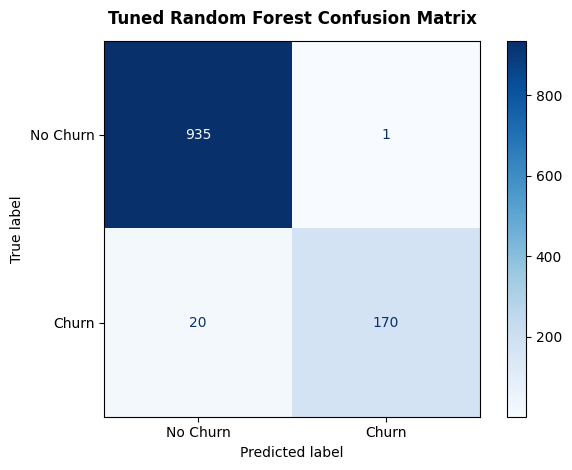

In [31]:
# Final tuned Random Forest model evaluation
best_rf_churn = grid_search_churn.best_estimator_
y_pred_tuned_churn = best_rf_churn.predict(X_test_churn)

tuned_accuracy_churn = accuracy_score(y_test_churn, y_pred_tuned_churn)
tuned_macro_f1_churn = f1_score(y_test_churn, y_pred_tuned_churn, average="macro")

baseline_macro_f1_churn = f1_score(y_test_churn, y_pred_baseline_churn, average="macro")

print("Baseline Test Accuracy:", baseline_accuracy_churn)
print("Baseline Test Macro F1:", baseline_macro_f1_churn)

print("\nTuned Test Accuracy:", tuned_accuracy_churn)
print("Tuned Test Macro F1:", tuned_macro_f1_churn)

print("\nBest GridSearch CV Macro F1:")
print(grid_search_churn.best_score_)

print("\nBest Parameters:")
print(grid_search_churn.best_params_)

print("\nTuned Classification Report:")
print(classification_report(y_test_churn, y_pred_tuned_churn, target_names=["No Churn", "Churn"]))

cm_tuned_churn = confusion_matrix(y_test_churn, y_pred_tuned_churn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned_churn,display_labels=["No Churn", "Churn"])

disp.plot(cmap="Blues")
plt.title("Tuned Random Forest Confusion Matrix", fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

The tuned model remains strong but does not improve on the baseline holdout result. Baseline accuracy and macro F1 are about **0.983** and **0.969**, compared with about **0.981** and **0.965** for the tuned model.

The baseline model is therefore retained for feature-importance analysis.

### 3.8 Feature Importance

Feature importance is calculated from the baseline Random Forest because it produced the stronger holdout result.

,Feature,Importance
0,Tenure,0.200511
12,CashbackAmount,0.094568
2,WarehouseToHome,0.075488
7,Complain,0.063868
6,NumberOfAddress,0.062051
8,OrderAmountHikeFromlastYear,0.059253
11,DaySinceLastOrder,0.057561
5,SatisfactionScore,0.049984
4,NumberOfDeviceRegistered,0.038463
10,OrderCount,0.032374


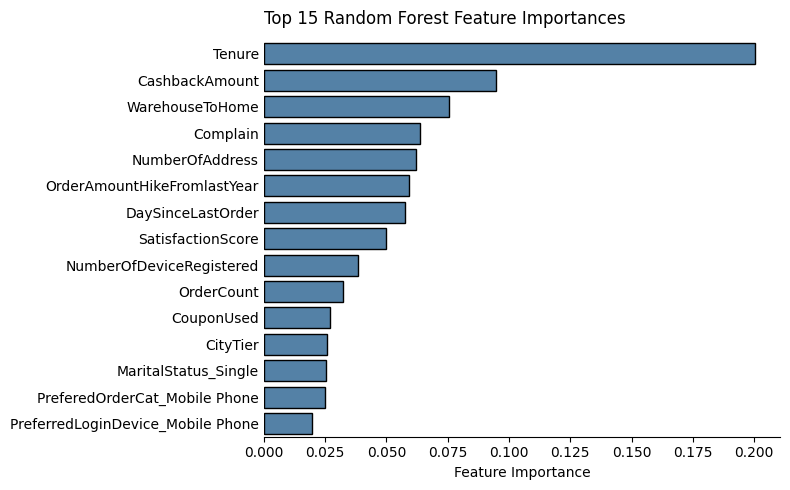

In [32]:
feature_importance_churn = pd.DataFrame({
    "Feature": X_train_churn.columns,
    "Importance": rf_baseline_churn.feature_importances_}).sort_values("Importance",ascending=False)

display(feature_importance_churn.head(15))

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=feature_importance_churn.head(15),x="Importance",y="Feature",color="steelblue",edgecolor="black")

ax.set_title("Top 15 Random Forest Feature Importances",fontsize=12, loc="left",pad=12)
ax.set_xlabel("Feature Importance")
ax.set_ylabel(None)
ax.tick_params(axis="y", length=0, labelsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

`Tenure` is the strongest feature, followed by `CashbackAmount`, `WarehouseToHome`, `Complain`, `NumberOfAddress`, and `DaySinceLastOrder`.

These rankings are consistent with the earlier EDA, particularly the relationship between shorter tenure and churn. They indicate which variables the model relies on most, but they do not establish causal effects.

### 3.9 Modeling Summary

Dataset 3 provides the strongest predictive signal of the four datasets. The baseline Random Forest reaches approximately **0.983 test accuracy** and **0.969 macro F1**, while five-fold cross-validation averages about **0.966 accuracy** and **0.935 macro F1**.

The strength of these results should still be interpreted cautiously. External or temporal validation would be important before assuming similar performance on new customer populations.

## 4. Purchase Experience — High-Value Order Classification

Dataset 4 is reframed as a binary classification problem. `High_Value_Order` identifies transactions in the top 25% of `Total_Amount`, while direct components of transaction value are excluded from the predictor set.

### 4.1 Load Prepared Data

In [33]:
df_purchase_experience = pd.read_pickle(DATA_DIR / "df_purchase_experience_eda.pkl")

df_purchase_experience.shape

(5000, 18)

### 4.2 Target Definition and Class Balance

`High_Value_Order` is defined as an order at or above the dataset's 75th percentile of `Total_Amount`. This creates a 25% positive class.

To avoid an obvious prediction, `Total_Amount`, `Unit_Price`, `Quantity`, and `Discount_Amount` are excluded from the predictors.

High-value threshold:
979.6949999999999

Target value counts:


High_Value_Order
0    3750
1    1250
Name: count, dtype: int64


Target class percentage:


High_Value_Order
0    75.0
1    25.0
Name: proportion, dtype: float64

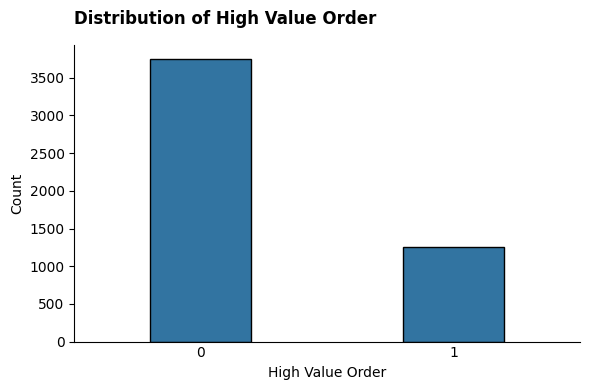

In [34]:
target_purchase = "High_Value_Order"

high_value_threshold_purchase = df_purchase_experience["Total_Amount"].quantile(0.75)

df_purchase_model = df_purchase_experience.copy()

df_purchase_model[target_purchase] = (df_purchase_model["Total_Amount"] >= high_value_threshold_purchase).astype(int)

print("High-value threshold:")
print(high_value_threshold_purchase)

print("\nTarget value counts:")
display(df_purchase_model[target_purchase].value_counts())

print("\nTarget class percentage:")
display(df_purchase_model[target_purchase].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_purchase_model, x=target_purchase, width=0.4, edgecolor="black")
plt.title("Distribution of High Value Order", loc="left", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("High Value Order")
plt.ylabel("Count")
ax.tick_params(axis="x", length=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

The high-value threshold is approximately **979.69**. The resulting target contains **75% non-high-value** and **25% high-value** orders, so stratification is used for the train/test split.

### 4.3 Feature Selection and Train/Test Split

Identifiers, the target source, direct price-mechanics variables, and post-purchase variables (`Customer_Rating` and `Delivery_Time_Days`) are excluded. Month and day-of-week are derived from `Date`, and categorical variables are one-hot encoded.

In [35]:
# Derive simple calendar features
df_purchase_model["Order_Month"] = (df_purchase_model["Date"].dt.month.astype("category"))
df_purchase_model["Order_DayOfWeek"] = (df_purchase_model["Date"].dt.dayofweek.astype("category"))

df_purchase_model["Is_Returning_Customer"] = (df_purchase_model["Is_Returning_Customer"].astype(int))

columns_to_remove_purchase = ["Order_ID","Customer_ID","Date","High_Value_Order","Total_Amount","Unit_Price","Quantity","Discount_Amount","Customer_Rating","Delivery_Time_Days",]

X_purchase = df_purchase_model.drop(columns=columns_to_remove_purchase)
y_purchase = df_purchase_model["High_Value_Order"]

X_purchase_encoded = pd.get_dummies(X_purchase,drop_first=True,dtype=int)

X_train_purchase, X_test_purchase, y_train_purchase, y_test_purchase = train_test_split(X_purchase_encoded,y_purchase,test_size=0.2,random_state=42, stratify=y_purchase)

print("Training shape:", X_train_purchase.shape)
print("Test shape:", X_test_purchase.shape)

print("\nTraining target balance:")
display(y_train_purchase.value_counts(normalize=True) * 100)

print("\nTest target balance:")
display(y_test_purchase.value_counts(normalize=True) * 100)

Training shape: (4000, 45)
Test shape: (1000, 45)

Training target balance:


High_Value_Order
0    75.0
1    25.0
Name: proportion, dtype: float64


Test target balance:


High_Value_Order
0    75.0
1    25.0
Name: proportion, dtype: float64

After encoding, the model uses 45 predictors. Stratification preserves the 75/25 target split in both training and test data.

### 4.4 Baseline Random Forest

In [36]:
baseline_rf_purchase = RandomForestClassifier(n_estimators=300,random_state=42,class_weight="balanced",n_jobs=-1)

baseline_rf_purchase.fit(X_train_purchase, y_train_purchase)

y_pred_baseline_purchase = baseline_rf_purchase.predict(X_test_purchase)
y_proba_baseline_purchase = baseline_rf_purchase.predict_proba(X_test_purchase)[:, 1]

baseline_results_purchase = pd.DataFrame({
    "Model": ["Baseline Random Forest"],
    "Accuracy": [accuracy_score(y_test_purchase, y_pred_baseline_purchase)],
    "Precision": [precision_score(y_test_purchase, y_pred_baseline_purchase)],
    "Recall": [recall_score(y_test_purchase, y_pred_baseline_purchase)],
    "F1": [f1_score(y_test_purchase, y_pred_baseline_purchase)],
    "ROC_AUC": [roc_auc_score(y_test_purchase, y_proba_baseline_purchase)]
})

display(baseline_results_purchase)

print("Confusion Matrix:")
print(confusion_matrix(y_test_purchase, y_pred_baseline_purchase))

print("\nClassification Report:")
print(classification_report(y_test_purchase, y_pred_baseline_purchase))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Baseline Random Forest,0.838,0.72,0.576,0.64,0.891488


Confusion Matrix:
[[694  56]
 [106 144]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       750
           1       0.72      0.58      0.64       250

    accuracy                           0.84      1000
   macro avg       0.79      0.75      0.77      1000
weighted avg       0.83      0.84      0.83      1000



The baseline model reaches **0.838 accuracy**, **0.640 F1**, and **0.891 ROC-AUC**. It predicts the majority class more easily; recall for high-value orders is about **0.576**, so a substantial share of high-value orders are missed.

### 4.5 Cross-Validation

In [37]:
cv_purchase = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

cv_scoring_purchase = {"accuracy": "accuracy","precision": "precision","recall": "recall","f1": "f1","roc_auc": "roc_auc"}

cv_results_purchase = cross_validate(
    baseline_rf_purchase,
    X_purchase_encoded,
    y_purchase,
    cv=cv_purchase,
    scoring=cv_scoring_purchase,
    n_jobs=-1
)

cv_summary_purchase = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"],
    "Mean": [cv_results_purchase["test_accuracy"].mean(),cv_results_purchase["test_precision"].mean(),cv_results_purchase["test_recall"].mean(),cv_results_purchase["test_f1"].mean(),cv_results_purchase["test_roc_auc"].mean()],
    "Standard Deviation": [cv_results_purchase["test_accuracy"].std(),cv_results_purchase["test_precision"].std(),cv_results_purchase["test_recall"].std(),cv_results_purchase["test_f1"].std(),cv_results_purchase["test_roc_auc"].std()]
})

cv_summary_purchase

,Metric,Mean,Standard Deviation
0,Accuracy,0.829200,0.010998
1,Precision,0.727591,0.034689
2,Recall,0.508000,0.029611
3,F1,0.597724,0.026557
4,ROC_AUC,0.882413,0.008498


Cross-validation closely matches the holdout result, with mean accuracy of about **0.829**, mean F1 of about **0.598**, and mean ROC-AUC of about **0.882**. The relatively small standard deviations suggest stable performance across folds.

### 4.6 Hyperparameter Tuning

F1 is used as the grid-search objective because the positive high-value class is smaller and both precision and recall matter.

In [38]:
rf_tuning_purchase = RandomForestClassifier(random_state=42,n_jobs=-1)

param_grid_purchase = {
    "n_estimators": [200, 300, 400],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf":  [2],
    "class_weight": ["balanced", "balanced_subsample"]
}

grid_search_purchase = GridSearchCV(estimator=rf_tuning_purchase,param_grid=param_grid_purchase,cv=cv_purchase,scoring="f1",n_jobs=-1)

grid_search_purchase.fit(X_train_purchase, y_train_purchase)

print("Best parameters:")
print(grid_search_purchase.best_params_)

print("\nBest CV F1:")
print(grid_search_purchase.best_score_)

Best parameters:
{'class_weight': 'balanced_subsample', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 400}

Best CV F1:
0.6769816241985467


The best configuration uses 400 trees, `max_depth=10`, `min_samples_leaf=2`, `min_samples_split=5`, and `class_weight="balanced_subsample"`. Its best cross-validation F1 is about **0.677**.

### 4.7 Final Tuned Model Evaluation

In [39]:
best_rf_purchase = grid_search_purchase.best_estimator_

y_pred_tuned_purchase = best_rf_purchase.predict(X_test_purchase)
y_proba_tuned_purchase = best_rf_purchase.predict_proba(X_test_purchase)[:, 1]

tuned_results_purchase = pd.DataFrame({
    "Model": ["Tuned Random Forest"],
    "Accuracy": [accuracy_score(y_test_purchase, y_pred_tuned_purchase)],
    "Precision": [precision_score(y_test_purchase, y_pred_tuned_purchase)],
    "Recall": [recall_score(y_test_purchase, y_pred_tuned_purchase)],
    "F1": [f1_score(y_test_purchase, y_pred_tuned_purchase)],
    "ROC_AUC": [roc_auc_score(y_test_purchase, y_proba_tuned_purchase)]
})

display(tuned_results_purchase)

print("Confusion Matrix:")
print(confusion_matrix(y_test_purchase, y_pred_tuned_purchase))

print("\nClassification Report:")
print(classification_report(y_test_purchase, y_pred_tuned_purchase))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Tuned Random Forest,0.806,0.577348,0.836,0.683007,0.88656


Confusion Matrix:
[[597 153]
 [ 41 209]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.80      0.86       750
           1       0.58      0.84      0.68       250

    accuracy                           0.81      1000
   macro avg       0.76      0.82      0.77      1000
weighted avg       0.85      0.81      0.82      1000



The tuned model shifts the operating trade-off toward identifying more high-value orders. Recall increases from **0.576 to 0.836** and F1 from **0.640 to 0.683**, while precision falls to about **0.577** and overall accuracy falls from **0.838 to 0.806**.

If missing high-value orders is more costly than reviewing additional false positives, this tuned configuration provides the more recall-oriented operating point.

### 4.8 Feature Importance

Feature importance is reviewed from the tuned Random Forest.

,Feature,Importance
16,Product_Category_Electronics,0.307546
18,Product_Category_Food,0.113381
15,Product_Category_Books,0.109215
19,Product_Category_Home & Garden,0.101939
20,Product_Category_Sports,0.053862
21,Product_Category_Toys,0.049284
0,Age,0.037039
1,Session_Duration_Minutes,0.033979
2,Pages_Viewed,0.027875
17,Product_Category_Fashion,0.016675


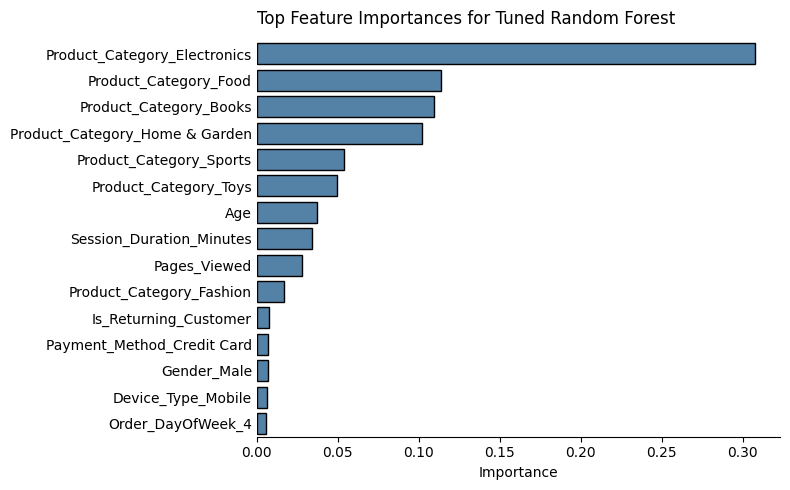

In [40]:
feature_importance_purchase = pd.DataFrame({"Feature": X_train_purchase.columns,"Importance": best_rf_purchase.feature_importances_}).sort_values("Importance", ascending=False)

display(feature_importance_purchase.head(15))

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=feature_importance_purchase.head(15),x="Importance",y="Feature",color="steelblue",edgecolor="black")

ax.set_title("Top Feature Importances for Tuned Random Forest",fontsize=12,loc="left",pad=12)
ax.set_xlabel("Importance")
ax.set_ylabel(None)
ax.tick_params(axis="y", length=0, labelsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

Product category is the dominant source of predictive signal after direct price variables are removed. `Product_Category_Electronics` has the highest individual importance, followed by several other product-category indicators.

Age, session duration, and pages viewed contribute smaller amounts of signal. These feature importances describe the fitted model and should not be interpreted causally.

### 4.9 Modeling Summary

The tuned Random Forest reaches approximately **0.806 accuracy**, **0.683 F1**, **0.836 recall**, and **0.887 ROC-AUC** for the high-value-order task.

The final model intentionally excludes `Total_Amount` and its direct transaction-value components, so the remaining performance reflects indirect signals such as product category, customer characteristics, browsing behavior, device, payment method, and calendar context.

## Cross-Dataset Modeling Takeaways

The four modeling tasks produced meaningfully different outcomes:

- **User Behavior & Engagement:** moderate and stable predictive signal for add-to-cart behavior. Engagement variables (`Share`, `Like`, and browsing time) were the strongest features.
- **Sales & Customer Insights:** no meaningful predictive signal for `Churn_Probability`; tuned test R² remained slightly negative. This dataset was retained as a negative modeling result rather than forced into a successful model.
- **Customer Churn:** the strongest predictive dataset, with high holdout and cross-validation performance. `Tenure` was the dominant feature, followed by cashback, delivery distance, complaints, and recent-order behavior.
- **Purchase Experience:** useful high-value-order classification after removing direct transaction-value variables. Hyperparameter tuning increased recall substantially at the cost of lower precision and accuracy.

Overall, the project demonstrates that model quality depends heavily on the information contained in the dataset. Strong modeling practice includes not only tuning successful models, but also recognizing weak signal, evaluating class imbalance, checking stability with cross-validation, and avoiding obvious leakage.

For a production workflow, preprocessing steps such as imputation and categorical encoding should be placed inside scikit-learn pipelines so that transformations are learned within each training or cross-validation fold. External or time-based validation would also be needed before deployment.